In [5]:
import pandas as pd
df = pd.read_excel(r"data\raw\Agnamarket.xlsx", header=1)
df.shape


(1632, 8)

In [6]:
df.columns.tolist()


['State/UT',
 'Commodity Group',
 'Commodity',
 'Month',
 'Arrival Quantity 03-02-2023 to 03-09-2026',
 'Arrival Unit',
 'Modal Price 03-02-2023 to 03-09-2026',
 'Price Unit']

In [7]:
df.head(10)


,State/UT,Commodity Group,Commodity,Month,Arrival Quantity 03-02-2023 to 03-09-2026,Arrival Unit,Modal Price 03-02-2023 to 03-09-2026,Price Unit
0,Telangana,Vegetables,Alsandikai,February-2023,0.30,Metric Tonnes,2500.00,Rs./Quintal
1,Telangana,Vegetables,Banana - Green,February-2023,2152.60,Metric Tonnes,2012.93,Rs./Quintal
2,Telangana,Vegetables,Beetroot,February-2023,2107.40,Metric Tonnes,1075.81,Rs./Quintal
3,Telangana,Vegetables,Bhindi(Ladies Finger),February-2023,1901.70,Metric Tonnes,3756.68,Rs./Quintal
4,Telangana,Vegetables,Bitter gourd,February-2023,2125.00,Metric Tonnes,2470.02,Rs./Quintal
5,Telangana,Vegetables,Bottle gourd,February-2023,2878.05,Metric Tonnes,691.33,Rs./Quintal
6,Telangana,Vegetables,Brinjal,February-2023,4562.37,Metric Tonnes,1874.91,Rs./Quintal
7,Telangana,Vegetables,Cabbage,February-2023,5133.79,Metric Tonnes,682.42,Rs./Quintal
8,Telangana,Vegetables,Capsicum,February-2023,2298.30,Metric Tonnes,3315.84,Rs./Quintal
9,Telangana,Vegetables,Carrot,February-2023,7178.84,Metric Tonnes,1233.42,Rs./Quintal


In [8]:
df.isna().sum()


State/UT                                     1
Commodity Group                              3
Commodity                                    3
Month                                        3
Arrival Quantity 03-02-2023 to 03-09-2026    3
Arrival Unit                                 3
Modal Price 03-02-2023 to 03-09-2026         3
Price Unit                                   3
dtype: int64

In [9]:
df = df.dropna()
df = df.rename(columns={
    "Arrival Quantity 03-02-2023 to 03-09-2026": "Arrival_Quantity",
    "Modal Price 03-02-2023 to 03-09-2026": "Modal_Price"
})
df.columns.tolist()


['State/UT',
 'Commodity Group',
 'Commodity',
 'Month',
 'Arrival_Quantity',
 'Arrival Unit',
 'Modal_Price',
 'Price Unit']

In [10]:
df["State/UT"].unique()
df["Commodity"].nunique()
df["Commodity Group"].unique()


<StringArray>
['Vegetables']
Length: 1, dtype: str

In [11]:
df["Month"].unique()


<StringArray>
[ 'February-2023',     'March-2023',     'April-2023',       'May-2023',
      'June-2023',      'July-2023',    'August-2023', 'September-2023',
   'October-2023',  'November-2023',  'December-2023',   'January-2024',
  'February-2024',     'March-2024',     'April-2024',       'May-2024',
      'June-2024',      'July-2024',    'August-2024', 'September-2024',
   'October-2024',  'November-2024',  'December-2024',   'January-2025',
  'February-2025',     'March-2025',     'April-2025',       'May-2025',
      'June-2025',      'July-2025',    'August-2025', 'September-2025',
   'October-2025',  'November-2025',  'December-2025',   'January-2026',
  'February-2026',     'March-2026',     'April-2026',       'May-2026',
      'June-2026',      'July-2026',    'August-2026', 'September-2026']
Length: 44, dtype: str

Demand Analysis — "Which items are most demanded?"

In [12]:
# Top 10 commodities by total arrivals
df.groupby("Commodity")["Arrival_Quantity"].sum().sort_values(ascending=False).head(10)


Commodity
Onion                    1900717.56
Tomato                    806984.09
Potato                    709942.89
Carrot                    375283.16
Green Chilli              363523.91
Cabbage                   234835.88
Brinjal                   167244.87
Bottle gourd              140619.05
Bhindi(Ladies Finger)     134748.05
Bitter gourd              129747.49
Name: Arrival_Quantity, dtype: float64

Price Hike Analysis — "Which items' prices rose most?"

In [13]:
# Average price per commodity per month → then compare first vs last month
monthly = df.groupby(["Commodity", "Month"])["Modal_Price"].mean().reset_index()

# Price trend for one commodity, e.g. Tomato
df[df["Commodity"] == "Tomato"].groupby("Month")["Modal_Price"].mean()


Month
April-2023         682.02
April-2024        1176.16
April-2025         870.28
April-2026        1216.84
August-2023       2002.88
August-2024       1267.05
August-2025       2384.07
August-2026       1058.80
December-2023     1270.67
December-2024     1241.22
December-2025     2149.21
February-2023     1259.89
February-2024     1072.39
February-2025      656.04
February-2026      662.31
January-2024      1250.82
January-2025       709.75
January-2026      1311.43
July-2023         8321.63
July-2024         3587.41
July-2025         1983.51
July-2026         1177.77
June-2023         2894.51
June-2024         3668.24
June-2025         1424.26
June-2026         2111.34
March-2023        1167.01
March-2024         731.51
March-2025         714.35
March-2026         643.18
May-2023           953.16
May-2024          1728.37
May-2025           927.92
May-2026          2088.41
November-2023     1615.56
November-2024     2157.67
November-2025     2069.79
October-2023       939.27
Octobe

What it does: Groups by commodity + month → shows the price JOURNEY over time. Comparing start vs end price = % hike per commodity. 💰

3️⃣ Regional Analysis — "Which regions dominate?"

In [14]:
# Arrivals per state
df.groupby("State/UT")["Arrival_Quantity"].sum().sort_values(ascending=False)


State/UT
Telangana    6132750.4
Name: Arrival_Quantity, dtype: float64

In [15]:
# Convert Month to proper datetime, then sort
df["Month_dt"] = pd.to_datetime(df["Month"], format="%B-%Y")
tomato = df[df["Commodity"] == "Tomato"].groupby("Month_dt")["Modal_Price"].mean().sort_index()
tomato


Month_dt
2023-02-01    1259.89
2023-03-01    1167.01
2023-04-01     682.02
2023-05-01     953.16
2023-06-01    2894.51
2023-07-01    8321.63
2023-08-01    2002.88
2023-09-01     816.22
2023-10-01     939.27
2023-11-01    1615.56
2023-12-01    1270.67
2024-01-01    1250.82
2024-02-01    1072.39
2024-03-01     731.51
2024-04-01    1176.16
2024-05-01    1728.37
2024-06-01    3668.24
2024-07-01    3587.41
2024-08-01    1267.05
2024-09-01    1987.83
2024-10-01    2998.09
2024-11-01    2157.67
2024-12-01    1241.22
2025-01-01     709.75
2025-02-01     656.04
2025-03-01     714.35
2025-04-01     870.28
2025-05-01     927.92
2025-06-01    1424.26
2025-07-01    1983.51
2025-08-01    2384.07
2025-09-01    1379.78
2025-10-01    1428.40
2025-11-01    2069.79
2025-12-01    2149.21
2026-01-01    1311.43
2026-02-01     662.31
2026-03-01     643.18
2026-04-01    1216.84
2026-05-01    2088.41
2026-06-01    2111.34
2026-07-01    1177.77
2026-08-01    1058.80
2026-09-01    1202.46
Name: Modal_Price, dtyp

#Biggest Price HIKES — ranked across ALL commodities 🏆
This is your headline analysis — which item's price rose the most over the whole period:

In [16]:
# First vs last month price per commodity → % change
pivot = df.pivot_table(index="Commodity", columns="Month_dt", values="Modal_Price", aggfunc="mean")
hike = ((pivot.iloc[:, -1] - pivot.iloc[:, 0]) / pivot.iloc[:, 0] * 100).dropna()
hike.sort_values(ascending=False).head(10)   # top 10 hikes
hike.sort_values().head(10)                  # top 10 DROPS (bonus insight!)


Commodity
Colacasia               -62.478776
Ridgeguard(Tori)        -58.195755
Bhindi(Ladies Finger)   -50.276574
Banana - Green          -49.492034
Bottle gourd            -38.975598
Drumstick               -34.951578
Cucumbar(Kheera)        -34.402644
Capsicum                -32.754295
Cluster beans           -30.748537
Little gourd(Kundru)    -28.000254
dtype: float64

Price VOLATILITY — which items are unstable/risky 🎢

In [17]:
df.groupby("Commodity")["Modal_Price"].std().sort_values(ascending=False).head(10)


Commodity
Garlic                    5608.482135
Coriander(Leaves)         4185.038752
Drumstick                 2859.766267
Ginger(Green)             1987.087443
French Beans(Frasbean)    1787.754905
Pointed gourd(Parval)     1682.064314
Tomato                    1274.310703
Yam(Ratalu)               1262.823798
Lemon                     1259.064970
Field Bean(Anumulu)       1148.633154
Name: Modal_Price, dtype: float64

High std = wild price swings = risky for buyers/sellers. Great dashboard insight!

 Cheapest & Most EXPENSIVE commodities 💸

In [18]:
df.groupby("Commodity")["Modal_Price"].mean().sort_values()          # cheapest
df.groupby("Commodity")["Modal_Price"].mean().sort_values(ascending=False).head(10)  # costliest


Commodity
Turmeric(raw)             12918.830000
Garlic                     9845.735750
Indian Beans(Seam)         6232.097500
Ginger(Green)              5562.278000
Turnip                     5000.000000
French Beans(Frasbean)     4650.582045
Drumstick                  4098.490909
Yam(Ratalu)                4091.494091
Little gourd(Kundru)       4006.878333
Groundnut pods(raw)        3981.117907
Name: Modal_Price, dtype: float64

 Demand + Price TOGETHER — the money question 💰

In [19]:
summary = df.groupby("Commodity").agg(
    Total_Arrivals=("Arrival_Quantity", "sum"),
    Avg_Price=("Modal_Price", "mean")
).sort_values("Total_Arrivals", ascending=False)
summary.head(15)


,Total_Arrivals,Avg_Price
Commodity,,
Onion,1900717.56,1787.011364
Tomato,806984.09,1658.170000
Potato,709942.89,1693.448409
Carrot,375283.16,2255.797273
Green Chilli,363523.91,3091.673409
Cabbage,234835.88,1106.649318
Brinjal,167244.87,1888.999773
Bottle gourd,140619.05,705.646364
Bhindi(Ladies Finger),134748.05,2207.201591


Shows which items are BOTH high-demand AND high-price = the market's money-makers.

 Seasonality — which months prices spike 

In [20]:
df["Month_num"] = df["Month_dt"].dt.month
df.groupby("Month_num")["Modal_Price"].mean()


Month_num
1     2225.307374
2     2312.864577
3     2087.214000
4     2246.620268
5     2670.411699
6     3020.014768
7     2986.134351
8     2629.555000
9     2618.316387
10    2821.198224
11    2845.223913
12    2967.921182
Name: Modal_Price, dtype: float64

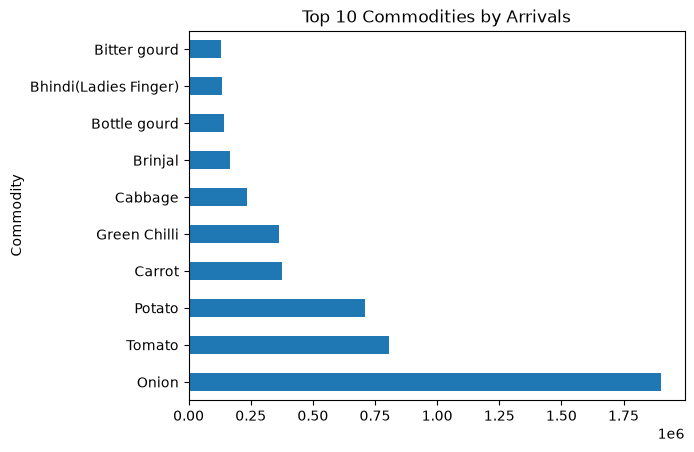

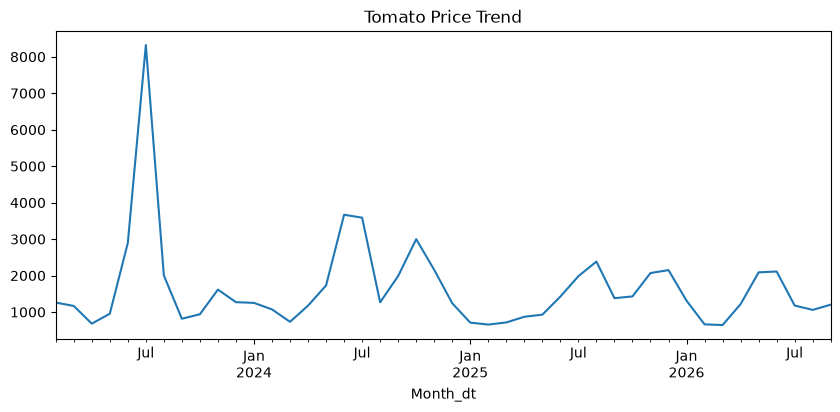

In [21]:
import matplotlib.pyplot as plt

# Top 10 demand bar chart
df.groupby("Commodity")["Arrival_Quantity"].sum().sort_values(ascending=False).head(10).plot(kind="barh", title="Top 10 Commodities by Arrivals")
plt.show()

# Tomato price trend line
tomato.plot(title="Tomato Price Trend", figsize=(10,4))
plt.show()


 Data Quality Audit — before trusting ANY result
A pro never shows numbers without checking them. 

In [22]:
df.describe()                          # any impossible values? negative prices? arrivals = 0?
df["Arrival_Quantity"].min(), df["Modal_Price"].min()
df.duplicated().sum()                  # duplicate rows?
df["Commodity"].value_counts()         # same commodity spelled differently? ("Tomato" vs "tomato")


Commodity
Banana - Green                        44
Beetroot                              44
Bhindi(Ladies Finger)                 44
Bitter gourd                          44
Bottle gourd                          44
Brinjal                               44
Cabbage                               44
Capsicum                              44
Carrot                                44
Cauliflower                           44
Chow Chow                             44
Cluster beans                         44
Colacasia                             44
Cucumbar(Kheera)                      44
Drumstick                             44
Field Pea                             44
French Beans(Frasbean)                44
Green Chilli                          44
Onion                                 44
Onion Green                           44
Potato                                44
Pumpkin                               44
Raddish                               44
Ridgeguard(Tori)                      44
Snakeg

In [23]:
df["Commodity"] = df["Commodity"].replace({
    "Ladies Finger": "Bhindi(Ladies Finger)"
})
df["Commodity"].nunique()   # should drop from 54 to 53


53

(If exploration reveals more duplicates later, we add them to this same mapping — this dictionary is called a "standardization map" and lives in the cleaning script.)